# Ecommerce Customers - Linear Regression

## Objective

The objective of this notebook is to build a Linear Regression model
to predict `Yearly Amount Spent` using customer behavioral variables.

The predictors are:

- Avg. Session Length
- Time on App
- Time on Website
- Length of Membership

The notebook covers:

1. Preparing the dataset
2. Creating a baseline prediction
3. Training a Linear Regression model
4. Understanding model coefficients
5. Generating predictions
6. Comparing actual and predicted values

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [2]:
df = pd.read_csv("../data/Ecommerce Customers.csv")

In [3]:
features = ["Avg. Session Length", "Time on App", "Time on Website", "Length of Membership"]

In [4]:
target = "Yearly Amount Spent"

In [5]:
X = df[features]
y = df[target]

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [9]:
# We should ask every time that my linear regression model is better than a baseline model (very simple prediction)
# So here we are taking the baseline model as the y_train mean so every customer is getting prediction as mean of the y_train data
baseline_prediction = y_train.mean()

baseline_prediction

np.float64(501.99215121245294)

In [10]:
# We are making our prediction for test data as baseline_prediction that is the mean of the y_train dataset
y_baseline_pred = np.full(
    shape=len(y_test),
    fill_value=baseline_prediction
)

In [12]:
# Every prediction is having same prediction that is the mean of the y_train data
y_baseline_pred[:10]

array([501.99215121, 501.99215121, 501.99215121, 501.99215121,
       501.99215121, 501.99215121, 501.99215121, 501.99215121,
       501.99215121, 501.99215121])

In [13]:
model = LinearRegression()

In [15]:
# It will calculate 5 coefficients that are β0, β1, β2, β3, β4
# As there are 4 features and 1 intercept
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](4,)","[25.6 ,38.79, 0.31,61.9 ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](4,)","['Avg. Session Length','Time on App','Time on Website', 'Length of Membership']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-1044
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,4
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(4)


In [17]:
# β0
model.intercept_

np.float64(-1044.2574146365573)

In [19]:
# β1, β2, β3, β4
model.coef_

array([25.5962591 , 38.78534598,  0.31038593, 61.89682859])

In [20]:
coefficients = pd.DataFrame({
    "Feature": features,
    "Coefficient": model.coef_
})

coefficients

,Feature,Coefficient
0,Avg. Session Length,25.596259
1,Time on App,38.785346
2,Time on Website,0.310386
3,Length of Membership,61.896829


In [23]:
print("Intercept: ", model.intercept_)

for feature, coefficient in zip(features, model.coef_):
    print(f"{feature}: {coefficient:.4f}")

Intercept:  -1044.2574146365573
Avg. Session Length: 25.5963
Time on App: 38.7853
Time on Website: 0.3104
Length of Membership: 61.8968


In [24]:
y_train_pred = model.predict(X_train)

In [25]:
y_test_pred = model.predict(X_test)

In [28]:
predictions = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_test_pred
})

predictions .head(10)

,Actual,Predicted
0,401.033135,402.862301
1,534.777188,542.533257
2,418.602742,426.620119
3,503.978379,501.913864
4,410.069611,409.666655
5,557.608262,569.921550
6,538.941975,531.504235
7,514.336558,505.943092
8,408.620188,408.103786
9,475.015407,473.459429


In [29]:
predictions["Residual"] = predictions["Actual"] - predictions["Predicted"]

In [30]:
predictions.head(10)

,Actual,Predicted,Residual
0,401.033135,402.862301,-1.829165
1,534.777188,542.533257,-7.756069
2,418.602742,426.620119,-8.017377
3,503.978379,501.913864,2.064515
4,410.069611,409.666655,0.402956
5,557.608262,569.921550,-12.313288
6,538.941975,531.504235,7.437739
7,514.336558,505.943092,8.393466
8,408.620188,408.103786,0.516402
9,475.015407,473.459429,1.555978


In [31]:
predictions["Absolute_Error"] = predictions["Residual"].abs()

In [33]:
predictions.head(10)

,Actual,Predicted,Residual,Absolute_Error
0,401.033135,402.862301,-1.829165,1.829165
1,534.777188,542.533257,-7.756069,7.756069
2,418.602742,426.620119,-8.017377,8.017377
3,503.978379,501.913864,2.064515,2.064515
4,410.069611,409.666655,0.402956,0.402956
5,557.608262,569.921550,-12.313288,12.313288
6,538.941975,531.504235,7.437739,7.437739
7,514.336558,505.943092,8.393466,8.393466
8,408.620188,408.103786,0.516402,0.516402
9,475.015407,473.459429,1.555978,1.555978


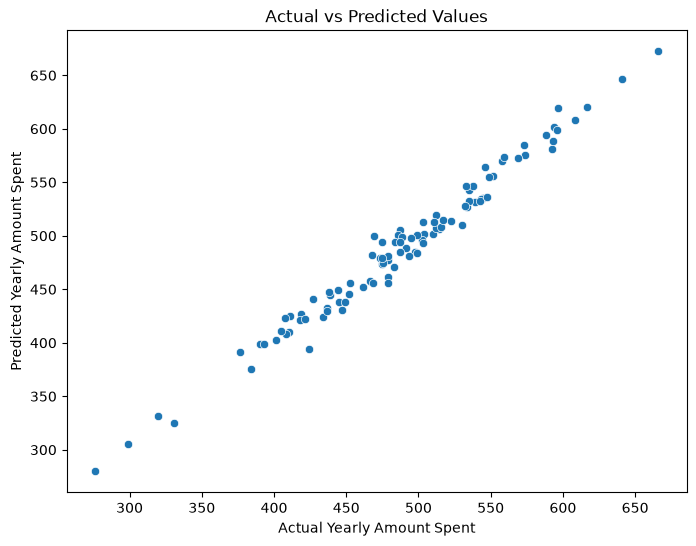

In [34]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=predictions["Actual"],
    y=predictions["Predicted"]
)

plt.xlabel("Actual Yearly Amount Spent")
plt.ylabel("Predicted Yearly Amount Spent")
plt.title("Actual vs Predicted Values")

plt.show()

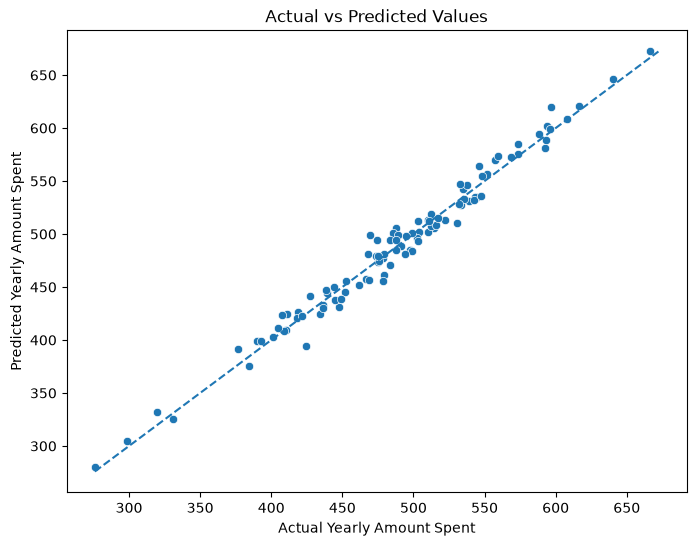

In [37]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=predictions["Actual"],
    y=predictions["Predicted"]
)

min_value = min(
    predictions["Actual"].min(),
    predictions["Predicted"].min()
)

max_value = max(
    predictions["Actual"].max(),
    predictions["Predicted"].max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Yearly Amount Spent")
plt.ylabel("Predicted Yearly Amount Spent")
plt.title("Actual vs Predicted Values")

plt.show()

In [39]:
predictions.to_csv(
    "../reports/linear_regression_predictions.csv",
    index=False
)

# Linear Regression Summary

## Model

A multiple Linear Regression model was trained using:

- Avg. Session Length
- Time on App
- Time on Website
- Length of Membership

The target variable is:

- Yearly Amount Spent

## Training

The model was trained using 80% of the dataset.

## Prediction

Predictions were generated for both the training and testing datasets.

## Interpretation

The model coefficients represent the estimated change in Yearly Amount
Spent associated with a one-unit increase in each predictor, while holding
the other included predictors constant.

## Baseline

A mean-based baseline was created so that the Linear Regression model can
later be compared against a simple non-learning prediction.

## Next Step

The next notebook will evaluate the model using MAE, MSE, RMSE, and R²,
and will analyze the model's residuals and generalization performance.